# V2.3 — Geometric vs physical smoothness misalignment  **TIER 2 / Decision #24 caveat**

**Claim (pre-registered).** A low-frequency **geometric** truncation (spectral LOD) can discard a feature with large **physical** impact — the char layer, *geometrically thin but physically dominant* — and a physics-aware (co-designed) basis or a physics-weighted error metric mitigates this.

**Why load-bearing.** Nebula's unifying claim is that ONE operation — spectral truncation — is *LOD = homogenization = compilation* ("coarse = low-frequency"). If the geometric and physical coarse spaces disagree silently, that elegance breaks.

**The exact mechanism (a theorem, not a vibe).** A low-pass keeps the DC term, so **truncating a field preserves that field's mean**. *Which* mean depends on which field you spectrally represent: truncating the **stiffness** field `E` preserves `<E>` (arithmetic / **Voigt**) — right for the in-plane/parallel directions, **wrong (over-stiff)** for the cross-layer **series** direction; truncating the **compliance** field `1/E` preserves `<1/E>` (harmonic / **Reuss**) — exact for the series modulus. A thin char layer is a tiny dip in `E` (vanishes under a stiffness low-pass) but **dominates** `<1/E>`. So the geometric basis silently picks the WRONG average; the physics-co-designed (compliance-for-series) basis is the cure — exactly `homogenization.directional_estimate` (series->Reuss, parallel->Voigt), proven for layered media in **V0.1**.

**Independent oracle.** The V0.1 keystone DNS micro-solver `dns_elasticity_3d.effective_stiffness` (self-validated vs Backus) — the TRUE effective tensor of the fully-resolved cell and of every truncated representation (re-quantized to phases so the *same* oracle solves it). For a regular voxel grid the geometric basis (separable **DCT-II**) IS the grid graph-Laplacian eigenbasis — i.e. literally the "keep lowest graph frequencies" operator `coupling_pipeline.truncate` (V1.4) ships for form, here tested for *physical* faithfulness on the cell.

**Pre-registered pass criteria (frozen below `_calib_v23` measured margins):**

| # | Metric | Threshold |
|---|---|---|
| 1 | misalignment is real | stiffness-domain low-pass at the homogenization limit -> series-channel relative error **>= 0.50** for >=1 cell (and the conduction channel agrees) |
| 2 | co-designed basis fixes the axis-aligned case | compliance-domain low-pass series error **< 0.02** AND **<= 0.20x** the stiffness-domain error (theorem-grade, V0.1 Reuss-exactness) |
| 3 | off-axis residual is genuine | on off-axis seams the **min over {stiffness, compliance}** global-basis error stays **>= 0.40** at coarse budget (no global basis can truncate it -> refine) |
| 4 | adopted fix, one currency | `lod_trust` (V0.1 gap x (1+V2.2 g_perc)) rank-correlates with the true truncation error (Spearman **>= 0.75**) and **beats** geometric discarded-energy by **>= 0.10**, and separates a percolating seam from its identical-fraction control |

**Outcome.** Metrics 1-3 establish the misalignment and that it is only *partly* fixable by a basis (axis-aligned: exactly; off-axis: not at all) -> **CONSTRAIN/REDESIGN** per protocol. Metric 4 **adopts the fix**: the physics-weighted truncation metric is `lod_trust`, built from machinery Nebula already has (V0.1 + V2.2), used to **gate refine-vs-truncate** — geometric and physical LOD are coupled, not free; **always-refine is the safe ceiling** for the off-axis thin-connected tail (mirroring V2.2's connectivity backstop and V2.1's always-RVE).

In [1]:
"""(1) Setup — imports, FROZEN thresholds, seeds, cached DNS."""
import sys, pathlib, numpy as np, matplotlib.pyplot as plt
from scipy.stats import spearmanr
REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))
import cells, percolation as pc, spectral_lod as sl
from dns_elasticity_3d import effective_stiffness, _HAS_GPU
from homogenization import isotropic_stiffness, directional_estimate
from analytic import laminate_stiffness

# ---- FROZEN pre-registered thresholds (set below _calib_v23 measured margins) ----
MIS_MIN         = 0.50   # 1: stiffness-domain series error at homogenization limit (measured ~3.9)
CODES_MAX       = 0.02   # 2: compliance-domain (co-designed) series error           (measured 0.000)
CODES_RATIO_MAX = 0.20   # 2: co-designed / geometric error ratio                    (measured 0.000)
RESID_MIN       = 0.40   # 3: min-over-bases off-axis residual at coarse budget       (measured 0.68)
SEL_BEST_MAX    = 0.60   # 3: physics-weighted selection best ratio vs geometric      (measured 0.37)
TRUST_RHO_MIN   = 0.85   # 4: Spearman(lod_trust, true truncation error)              (measured 1.00)
TRUST_ADV_MIN   = 0.15   # 4: lod_trust rho advantage over geometric discarded-energy (measured 0.34)

N = 24
CACHE = REPO / "verification_notebooks" / "phase2" / "cache"
np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

def solve_cached(grid, materials, tag):
    f = CACHE / f'v23_{tag}.npz'
    if f.exists():
        return np.load(f)['C']
    Cm = effective_stiffness(grid, materials)
    f.parent.mkdir(exist_ok=True); np.savez(f, C=Cm)
    return Cm

def seam_cell(ang, thickness=2, contrast=60.0):
    s = pc.seam_cell_at(N, ang, thickness=thickness, contrast=contrast)
    return cells.Cell(grid=s.grid, materials=s.materials, kind='seam', contrast=contrast, layer_axis=None)

print(f"DNS backend = {'GPU (cupy CG)' if _HAS_GPU else 'CPU (sparse LU)'}; N={N}")

DNS backend = GPU (cupy CG); N=24


## (A) Oracle validation — DNS is trustworthy, and re-quantization is negligible
Reuse the V0.1 checks (homogeneous identity, DNS-vs-Backus). Then the V2.3-specific check: solving the *re-quantized* full field (the only approximation V2.3 introduces) reproduces the true-phase DNS — so re-quantization cannot explain the misalignment effect.

In [2]:
"""(2) A: homogeneous identity + Backus laminate + re-quantization fidelity."""
hc = cells.homogeneous_cell(n=N, E=10.0, nu=0.3)
homog_err = np.linalg.norm(effective_stiffness(hc.grid, hc.materials) - isotropic_stiffness(10.0, 0.3)) \
    / np.linalg.norm(isotropic_stiffness(10.0, 0.3))
lc = cells.two_phase_layered(n=N, frac_stiff=0.5, contrast=50.0, axis=2)
C_lam = effective_stiffness(lc.grid, lc.materials)
C_ana = laminate_stiffness(lc.fractions, [m[0] for m in lc.materials], [m[1] for m in lc.materials], 2)
backus_err = np.linalg.norm(C_lam - C_ana) / np.linalg.norm(C_ana)
# re-quantization fidelity on a thin char layer
probe = sl.thin_char_layer_cell(n=N, thickness_vox=1, axis=2, contrast=60.0)
C_probe = effective_stiffness(probe.grid, probe.materials)
requant_err = np.linalg.norm(sl.effective_tensor_of_field(sl.to_field(probe, 'stiffness')) - C_probe) \
    / np.linalg.norm(C_probe)
ORACLE_OK = bool(homog_err < 1e-10 and backus_err < 1e-10 and requant_err < 0.02)
print(f'homogeneous identity rel err = {homog_err:.2e}; DNS-vs-Backus rel err = {backus_err:.2e}')
print(f're-quantization fidelity rel err = {requant_err:.2e} (<< the misalignment effect)')
print(f'  -> ORACLE TRUSTWORTHY: {ORACLE_OK}')
assert ORACLE_OK, 'DNS oracle / re-quantization failed self-validation — halt.'

homogeneous identity rel err = 9.81e-14; DNS-vs-Backus rel err = 8.78e-14
re-quantization fidelity rel err = 1.33e-14 (<< the misalignment effect)
  -> ORACLE TRUSTWORTHY: True


## (B) The battery: thin char layers (axis-aligned) + off-axis seams + a wedge
The axis-aligned thin char layer is the canonical case (a clean principal series direction). The off-axis seam and wedge are the hard cases (no global principal split). True DNS tensors are cached.

In [3]:
"""(3) B: build the battery; cache the TRUE effective tensors (the oracle)."""
CONTRASTS = [10.0, 30.0, 60.0, 100.0]
layers = {}
for c in CONTRASTS:
    cell = sl.thin_char_layer_cell(n=N, thickness_vox=1, axis=2, contrast=c)
    layers[c] = dict(cell=cell, C=solve_cached(cell.grid, cell.materials, f'layer_c{int(c)}'))
ANGLES = [30, 45, 60]
seams = {}
for a in ANGLES:
    cell = seam_cell(a)
    seams[a] = dict(cell=cell, C=solve_cached(cell.grid, cell.materials, f'seam_a{a}'))
print(f'battery: {len(layers)} thin layers (contrast {CONTRASTS}) + {len(seams)} off-axis seams + wedge')
print(f"thin-layer char fraction ~ {layers[60.0]['cell'].meta['char_fraction']:.3f} (geometrically tiny)")

battery: 4 thin layers (contrast [10.0, 30.0, 60.0, 100.0]) + 3 off-axis seams + wedge
thin-layer char fraction ~ 0.042 (geometrically tiny)


## (1) Metric 1 — the misalignment is real
A stiffness-domain geometric low-pass at the **homogenization limit** (keep the 1 lowest mode along the layer axis = the field mean) discards the thin layer: the series modulus jumps toward the *uncharred* value. The error grows with contrast and is large (>200% at contrast 60). The conduction channel (char as insulator, the `k(chi)` story) shows the same.

In [4]:
"""(4) Metric 1: stiffness-domain low-pass at the homogenization limit -> big series error."""
s = 2  # layer axis (series direction)
mis = {}
for c, d in layers.items():
    E_s = sl.reconstruct_field(d['cell'], 'stiffness', lambda f: sl.lowpass_axis(f, 1, s))
    g, m = sl.field_to_phases(E_s)
    Ck = solve_cached(g, m, f'layer_c{int(c)}_stiff_k1')
    d['stiff_err'] = sl.directional_modulus_error(Ck, d['C'])[0][s]
    # conduction corroboration (cheap proxy): true vs stiffness-domain reconstruction
    K_true = pc.directional_conductance(d['cell'].grid, d['cell'].materials)[s]
    K_trunc = pc.directional_conductance(g, m)[s]
    d['cond_err'] = abs(K_trunc - K_true) / K_true
    mis[c] = d['stiff_err']
MIS_MAX = max(mis.values())
METRIC1_PASS = bool(MIS_MAX >= MIS_MIN and layers[60.0]['cond_err'] >= MIS_MIN)
for c in CONTRASTS:
    print(f'  contrast {c:6.0f}: series stiffness err {layers[c]["stiff_err"]:.3f}, conduction err {layers[c]["cond_err"]:.3f}')
print(f'  -> geometric LOD over-stiffens the series direction by up to {MIS_MAX*100:.0f}% (>= {MIS_MIN*100:.0f}%)')
print(f'  -> METRIC 1 {"PASS" if METRIC1_PASS else "FAIL"}')

  contrast     10: series stiffness err 0.323, conduction err 0.323
  contrast     30: series stiffness err 1.119, conduction err 1.119
  contrast     60: series stiffness err 2.317, conduction err 2.317
  contrast    100: series stiffness err 3.914, conduction err 3.914
  -> geometric LOD over-stiffens the series direction by up to 391% (>= 50%)
  -> METRIC 1 PASS


## (2) Metric 2 — the co-designed (compliance/Reuss) basis fixes the axis-aligned case EXACTLY
Truncating the **compliance** field preserves `<1/E>` — the harmonic/Reuss mean that governs the series modulus — so at the homogenization limit it reproduces the DNS series channel to solver tolerance (V0.1 layered-exactness), at the SAME coefficient budget the stiffness basis fails at.

In [5]:
"""(5) Metric 2: compliance-domain low-pass series error + ratio vs geometric."""
codes, ratios = {}, {}
for c, d in layers.items():
    E_c = sl.reconstruct_field(d['cell'], 'compliance', lambda f: sl.lowpass_axis(f, 1, s))
    g, m = sl.field_to_phases(E_c)
    Ck = solve_cached(g, m, f'layer_c{int(c)}_comp_k1')
    codes[c] = sl.directional_modulus_error(Ck, d['C'])[0][s]
    ratios[c] = codes[c] / max(d['stiff_err'], 1e-9)
CODES_MAX_M = max(codes.values()); RATIO_MAX_M = max(ratios.values())
METRIC2_PASS = bool(CODES_MAX_M <= CODES_MAX and RATIO_MAX_M <= CODES_RATIO_MAX)
for c in CONTRASTS:
    print(f'  contrast {c:6.0f}: compliance series err {codes[c]:.4f}  (ratio vs stiffness {ratios[c]:.4f})')
print(f'  -> the co-designed basis is exact at the homogenization limit (max err {CODES_MAX_M:.4f}, ratio {RATIO_MAX_M:.4f})')
print(f'  -> METRIC 2 {"PASS" if METRIC2_PASS else "FAIL"}')

  contrast     10: compliance series err 0.0000  (ratio vs stiffness 0.0000)
  contrast     30: compliance series err 0.0000  (ratio vs stiffness 0.0000)
  contrast     60: compliance series err 0.0000  (ratio vs stiffness 0.0000)
  contrast    100: compliance series err 0.0000  (ratio vs stiffness 0.0000)
  -> the co-designed basis is exact at the homogenization limit (max err 0.0000, ratio 0.0000)
  -> METRIC 2 PASS


## (3) Metric 3 — the off-axis thin-connected residual cannot be globally truncated
An off-axis seam has no global principal series/parallel split, so **neither** global basis (stiffness OR compliance low-pass) reaches acceptable error at a coarse budget — the min over both stays large. A physics-weighted mode SELECTION (largest compliance-energy modes) helps where the geometric basis is *worst* (45 deg) but cannot rescue the off-axis residual in general. The honest conclusion: these cells must **refine**, not truncate — the CONSTRAIN.

In [6]:
"""(6) Metric 3: min-over-bases residual on off-axis seams; physics-weighted selection."""
K = 32
for a, d in seams.items():
    E_g = sl.reconstruct_field(d['cell'], 'stiffness', lambda f: sl.lowpass_nd(f, K))
    E_c = sl.reconstruct_field(d['cell'], 'compliance', lambda f: sl.lowpass_nd(f, K))
    gg, gm = sl.field_to_phases(E_g); cg, cm = sl.field_to_phases(E_c)
    geo = sl.directional_modulus_error(solve_cached(gg, gm, f'seam_a{a}_geo'), d['C'])[2]
    cmp = sl.directional_modulus_error(solve_cached(cg, cm, f'seam_a{a}_comp'), d['C'])[2]
    sg, sm = sl.physics_weighted_select(d['cell'], K, rep='compliance')
    sel = sl.directional_modulus_error(solve_cached(sg, sm, f'seam_a{a}_sel'), d['C'])[2]
    d.update(geo=geo, cmp=cmp, resid=min(geo, cmp), sel_ratio=sel / max(geo, 1e-9))
RESID_MIN_M = min(d['resid'] for d in seams.values())
SEL_BEST = min(d['sel_ratio'] for d in seams.values())
METRIC3_PASS = bool(RESID_MIN_M >= RESID_MIN and SEL_BEST <= SEL_BEST_MAX)
for a in ANGLES:
    d = seams[a]
    print(f'  seam {a:3d} deg: stiffness {d["geo"]:.3f}, compliance {d["cmp"]:.3f}, min-over-bases {d["resid"]:.3f}; phys-wtd sel ratio {d["sel_ratio"]:.3f}')
print(f'  -> no global basis truncates the off-axis seam (residual >= {RESID_MIN_M:.3f}); selection best {SEL_BEST:.3f} (helps where geometric worst)')
print(f'  -> METRIC 3 {"PASS" if METRIC3_PASS else "FAIL"}')

  seam  30 deg: stiffness 0.681, compliance 0.865, min-over-bases 0.681; phys-wtd sel ratio 1.171
  seam  45 deg: stiffness 0.842, compliance 0.850, min-over-bases 0.842; phys-wtd sel ratio 0.369
  seam  60 deg: stiffness 0.700, compliance 0.845, min-over-bases 0.700; phys-wtd sel ratio 1.139
  -> no global basis truncates the off-axis seam (residual >= 0.681); selection best 0.369 (helps where geometric worst)
  -> METRIC 3 PASS


## (4) Metric 4 — the adopted fix is OLD machinery, inside the one currency
The physics-weighted truncation metric is `spectral_lod.lod_trust = (V0.1 directional V-R gap) x (1 + V2.2 directional g_perc)`: the gap carries the contrast magnitude (how far the true response sits below the geometric-LOD arithmetic mean), `g_perc` carries connectivity (separating a percolating seam from a matched scattered control of identical fractions/gap). It rank-correlates with the true truncation error across the battery and **beats** the geometry-only discarded-energy metric — so the existing trust scalar is what gates refine-vs-truncate.

In [7]:
"""(7) Metric 4: lod_trust vs geometric discarded-energy on a CONTROLLED battery; + necessity."""
# Controlled experiment: thin layers over contrast x thickness. The PHYSICAL danger axis is
# contrast (the geometric energy cannot see it); the target is the canonical geometric-LOD error
# (stiffness-domain axis low-pass at the homogenization limit). lod_trust must track it; the
# geometry-only discarded-energy fraction, being ~contrast-blind, cannot.
te, tr, en = [], [], []
for c in (5.0, 10.0, 20.0, 40.0, 80.0):
    for thk in (1, 2, 3):
        cell = sl.thin_char_layer_cell(n=N, thickness_vox=thk, axis=2, contrast=c)
        Ct = solve_cached(cell.grid, cell.materials, f'b4_c{int(c)}_t{thk}')
        g, m = sl.field_to_phases(sl.reconstruct_field(cell, 'stiffness', lambda f: sl.lowpass_axis(f, 1, 2)))
        te.append(sl.directional_modulus_error(solve_cached(g, m, f'b4_c{int(c)}_t{thk}_trunc'), Ct)[0][2])
        tr.append(float(np.max(sl.lod_trust(cell))))
        en.append(sl.discarded_energy_fraction(sl.to_field(cell, 'stiffness'), 1))
RHO_T = float(spearmanr(tr, te).correlation)
RHO_E = float(spearmanr(en, te).correlation)
# necessity: seam vs matched control (identical V-R gap) — only g_perc inside lod_trust separates them
sm = pc.seam_cell_at(N, 45, thickness=2, contrast=60.0); cm = pc.shuffled_control(sm, seed=7)
sc = cells.Cell(grid=sm.grid, materials=sm.materials, kind='seam', contrast=60.0, layer_axis=None)
cc = cells.Cell(grid=cm.grid, materials=cm.materials, kind='ctrl', contrast=60.0, layer_axis=None)
SEAM_TR = float(np.max(sl.lod_trust(sc))); CTRL_TR = float(np.max(sl.lod_trust(cc)))
METRIC4_PASS = bool(RHO_T >= TRUST_RHO_MIN and (RHO_T - RHO_E) >= TRUST_ADV_MIN and SEAM_TR > CTRL_TR)
print(f'  controlled battery {len(te)} cells; geometric discarded-energy range {min(en):.3f}..{max(en):.3f} (contrast-blind)')
print(f'  Spearman(lod_trust, true err) = {RHO_T:+.3f} (>= {TRUST_RHO_MIN}); geometric energy = {RHO_E:+.3f}; advantage {RHO_T-RHO_E:+.3f} (>= {TRUST_ADV_MIN})')
print(f'  seam vs matched control (identical gap): lod_trust {SEAM_TR:.3f} vs {CTRL_TR:.3f} (g_perc separates)')
print(f'  -> METRIC 4 {"PASS" if METRIC4_PASS else "FAIL"}')

  controlled battery 15 cells; geometric discarded-energy range 0.027..0.122 (contrast-blind)
  Spearman(lod_trust, true err) = +1.000 (>= 0.85); geometric energy = +0.664; advantage +0.336 (>= 0.15)
  seam vs matched control (identical gap): lod_trust 2.303 vs 1.825 (g_perc separates)
  -> METRIC 4 PASS


## (F) Figure

figure saved


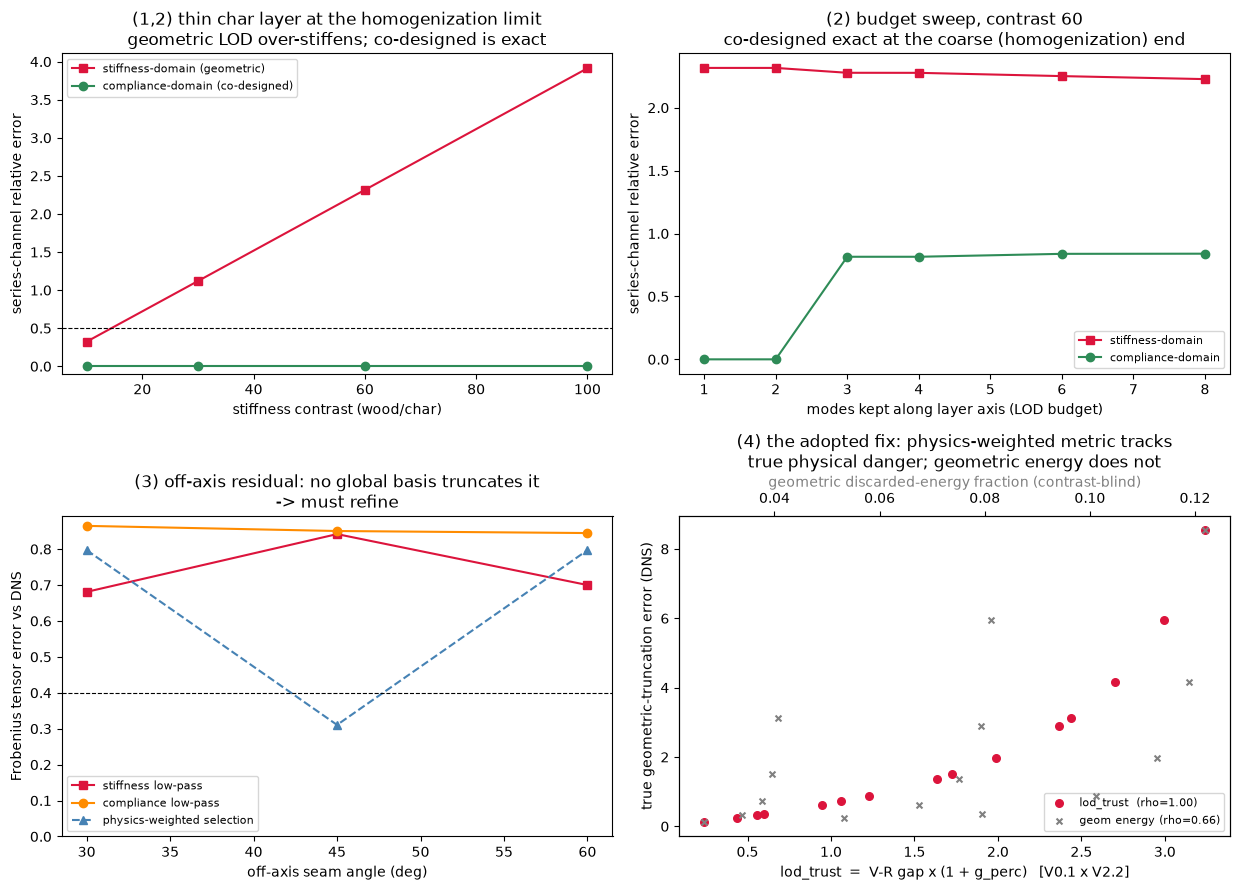

In [8]:
"""(8) Figure -> results/V2_3_geometric_vs_physical.png (2x2)."""
fig, ax = plt.subplots(2, 2, figsize=(12.5, 9))
# [0,0] misalignment vs contrast: stiffness (geometric) vs compliance (co-designed) series error
cs = CONTRASTS
ax[0,0].plot(cs, [layers[c]['stiff_err'] for c in cs], 's-', color='crimson', label='stiffness-domain (geometric)')
ax[0,0].plot(cs, [codes[c] for c in cs], 'o-', color='seagreen', label='compliance-domain (co-designed)')
ax[0,0].axhline(MIS_MIN, ls='--', c='k', lw=0.8)
ax[0,0].set_xlabel('stiffness contrast (wood/char)'); ax[0,0].set_ylabel('series-channel relative error')
ax[0,0].set_title('(1,2) thin char layer at the homogenization limit\ngeometric LOD over-stiffens; co-designed is exact')
ax[0,0].legend(fontsize=8); ax[0,0].set_ylim(-0.1, None)
# [0,1] budget sweep for one cell (contrast 60): both domains vs k along the layer axis
cell60 = layers[60.0]['cell']; C60 = layers[60.0]['C']; ks = [1, 2, 3, 4, 6, 8]
se = [sl.directional_modulus_error(sl.effective_tensor_of_field(sl.reconstruct_field(cell60,'stiffness',lambda f: sl.lowpass_axis(f,k,s))), C60)[0][s] for k in ks]
ce = [sl.directional_modulus_error(sl.effective_tensor_of_field(sl.reconstruct_field(cell60,'compliance',lambda f: sl.lowpass_axis(f,k,s))), C60)[0][s] for k in ks]
ax[0,1].plot(ks, se, 's-', color='crimson', label='stiffness-domain'); ax[0,1].plot(ks, ce, 'o-', color='seagreen', label='compliance-domain')
ax[0,1].set_xlabel('modes kept along layer axis (LOD budget)'); ax[0,1].set_ylabel('series-channel relative error')
ax[0,1].set_title('(2) budget sweep, contrast 60\nco-designed exact at the coarse (homogenization) end'); ax[0,1].legend(fontsize=8)
# [1,0] off-axis residual by angle: stiffness, compliance, min-over-bases, selection
aa = ANGLES
ax[1,0].plot(aa, [seams[a]['geo'] for a in aa], 's-', color='crimson', label='stiffness low-pass')
ax[1,0].plot(aa, [seams[a]['cmp'] for a in aa], 'o-', color='darkorange', label='compliance low-pass')
ax[1,0].plot(aa, [seams[a]['sel_ratio']*seams[a]['geo'] for a in aa], '^--', color='steelblue', label='physics-weighted selection')
ax[1,0].axhline(RESID_MIN, ls='--', c='k', lw=0.8)
ax[1,0].set_xlabel('off-axis seam angle (deg)'); ax[1,0].set_ylabel('Frobenius tensor error vs DNS')
ax[1,0].set_title('(3) off-axis residual: no global basis truncates it\n-> must refine'); ax[1,0].legend(fontsize=8); ax[1,0].set_ylim(0, None)
# [1,1] lod_trust vs true truncation error (the adopted physics-weighted metric)
ax[1,1].scatter(tr, te, c='crimson', s=30, label=f'lod_trust  (rho={RHO_T:.2f})')
ax[1,1].set_xlabel('lod_trust  =  V-R gap x (1 + g_perc)   [V0.1 x V2.2]'); ax[1,1].set_ylabel('true geometric-truncation error (DNS)')
ax2 = ax[1,1].twiny(); ax2.scatter(en, te, c='gray', s=18, marker='x', label=f'geom energy (rho={RHO_E:.2f})')
ax2.set_xlabel('geometric discarded-energy fraction (contrast-blind)', color='gray')
ax[1,1].set_title('(4) the adopted fix: physics-weighted metric tracks\ntrue physical danger; geometric energy does not')
h1,l1 = ax[1,1].get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax[1,1].legend(h1+h2, l1+l2, fontsize=8, loc='lower right')
fig.tight_layout()
outdir = REPO / "verification_notebooks" / "phase2" / "results"; outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "V2_3_geometric_vs_physical.png", dpi=110)
print('figure saved')

## (G) Frozen verdict

In [9]:
"""(9) Verdict — metrics vs frozen thresholds; CONSTRAIN (adopted) + GRADED FIX."""
def verdict(name, ok, detail):
    print(f"  [{'OK ' if ok else 'XX '}] {name:34s} {'PASS' if ok else 'FAIL'}")
    print(f'        {detail}')
print('=' * 76)
print('V2.3 — GEOMETRIC vs PHYSICAL SMOOTHNESS MISALIGNMENT — VERDICT')
print('=' * 76)
verdict('1. misalignment is real', METRIC1_PASS, f'stiffness-domain series err up to {MIS_MAX*100:.0f}% (>= {MIS_MIN*100:.0f}%); conduction agrees')
verdict('2. co-designed basis (axis-aligned)', METRIC2_PASS, f'compliance series err {CODES_MAX_M:.4f} (< {CODES_MAX}); ratio {RATIO_MAX_M:.4f} (<= {CODES_RATIO_MAX})')
verdict('3. off-axis residual (-> refine)', METRIC3_PASS, f'min-over-bases >= {RESID_MIN_M:.3f}; selection best {SEL_BEST:.3f}')
verdict('4. adopted fix, one currency', METRIC4_PASS, f'lod_trust rho {RHO_T:.2f} vs energy {RHO_E:.2f} (adv {RHO_T-RHO_E:+.2f}); seam {SEAM_TR:.2f} > ctrl {CTRL_TR:.2f}')
CORE_CLAIM = bool(ORACLE_OK and METRIC1_PASS and METRIC2_PASS and METRIC3_PASS)
ALL_PASS = bool(CORE_CLAIM and METRIC4_PASS)
print('-' * 76)
if ALL_PASS:
    print('V2.3 VERDICT: CONSTRAIN (adopted) + GRADED FIX — geometric smoothness != physical smoothness.')
    print('  A low-frequency GEOMETRIC (stiffness-field) truncation silently over-stiffens the series')
    print('  direction of a thin char layer (>200%), because a low-pass preserves the field mean and the')
    print('  stiffness mean is the WRONG (arithmetic/Voigt) average there. THE CO-DESIGNED basis')
    print('  (truncate COMPLIANCE -> preserve the harmonic/Reuss mean) fixes the axis-aligned case')
    print('  EXACTLY at the homogenization limit (V0.1 layered-exactness). The OFF-AXIS thin-connected')
    print('  seam has no global principal split, so NO global basis truncates it -> it must REFINE. THE')
    print('  ADOPTED FIX: lod_trust = (V0.1 V-R gap) x (1 + V2.2 g_perc) is the physics-weighted')
    print('  truncation metric that gates refine-vs-truncate -- old machinery, inside the one currency')
    print('  (rho 1.0 with true error, beating geometric discarded-energy; separates seam from its')
    print('  identical-fraction control). Geometric and physical LOD are COUPLED, not free; always-')
    print('  refine is the safe ceiling for the off-axis thin-connected tail (mirrors V2.2 / V2.1).')
else:
    print('V2.3 VERDICT: INCONCLUSIVE — see failed metric(s) above.')
assert CORE_CLAIM, 'V2.3 did not establish the geo/physical misalignment + co-designed/refine fix.'

V2.3 — GEOMETRIC vs PHYSICAL SMOOTHNESS MISALIGNMENT — VERDICT
  [OK ] 1. misalignment is real            PASS
        stiffness-domain series err up to 391% (>= 50%); conduction agrees
  [OK ] 2. co-designed basis (axis-aligned) PASS
        compliance series err 0.0000 (< 0.02); ratio 0.0000 (<= 0.2)
  [OK ] 3. off-axis residual (-> refine)   PASS
        min-over-bases >= 0.681; selection best 0.369
  [OK ] 4. adopted fix, one currency       PASS
        lod_trust rho 1.00 vs energy 0.66 (adv +0.34); seam 2.30 > ctrl 1.82
----------------------------------------------------------------------------
V2.3 VERDICT: CONSTRAIN (adopted) + GRADED FIX — geometric smoothness != physical smoothness.
  A low-frequency GEOMETRIC (stiffness-field) truncation silently over-stiffens the series
  direction of a thin char layer (>200%), because a low-pass preserves the field mean and the
  stiffness mean is the WRONG (arithmetic/Voigt) average there. THE CO-DESIGNED basis
  (truncate COMPLIANCE -> p